In [77]:
from opacities import *
from energies import *
from rho import *
from load1load2 import *
from derivs import *
from constants import *
from nabla_check import *

import numpy as np
import scipy 
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp

In [78]:
def int_load1_outwards(Rs, Pc, Ls, Tc):     
    # if not (3.75 <= np.log10(Tc) <= 7.5): 
    #     return -np.inf
        
  #  M_arr = np.logspace(np.log10(M_core_init), np.log10(M_intersect), niter)[1:-1]
    params = load1(M_core_init, comp, Pc, Tc) 
    
 #   print("load1_outwards int params:", params)
    
    sol_outwards = solve_ivp(derivs, t_span = [M_core_init, M_intersect], y0 = params, method = "Radau", dense_output=True)
    return sol_outwards

def int_load2_inwards(Rs, Pc, Ls, Tc):
   # niter = int(1e5)
   # M_intersect = 0.2 * Ms

    # if not (3.75 <= np.log10(Tc) <= 7.5): 
    #     return -np.inf
        
 #   M_arr = np.logspace(np.log10(Ms), np.log10(M_intersect), niter)
   # print(M_arr[2], M_arr[-2])
    params = load2(Ms, comp, Ls, Rs) 

    sol_inwards = solve_ivp(derivs, t_span = [Ms, M_intersect], y0 = params, method = "Radau", dense_output=True)
    return sol_inwards

In [79]:
def difference(params):
        
    Pc, Tc, Ls, Rs = params
  #  print("step:", Pc, Tc, Ls, Rs)

    # rhoc = rho_eq(Pc, Tc, comp)
    # R = rhoc / (Tc*1e-6)**3 # calc R from T and rho 
    # logR = np.log10(R) # take log of R 
    
    # logT=np.log10(Tc)

    # if not(-8.0 < logR < 1.0):
    #     print("log R bad in difference")
    #     return np.ones(4) * np.inf
    # if not (3.75 <= logT <= 7.5): 
    #     print("log T bad")
    #     return np.ones(4) * np.inf

    results_in = int_load2_inwards(Rs, Pc, Ls, Tc).y
  #  print(results_in)
    # Ps_in = results_in[1]
    # Ts_in = results_in[3]
   # print("rho", rho_eq(Ps_in, Ts_in, comp))

    results_out = int_load1_outwards(Rs, Pc, Ls, Tc).y
    #print(results_out)

    if not (3.75 <= np.log10(results_in[-1][-1]) <= 7.5):
        print("log T bad in load1")
        return np.ones(4) * np.inf

    # check radius
    if results_in[0][-1] < 0: 
        print("bad radius in")
        return -np.ones(4) * np.inf
    if results_out[0][-1] < 0: 
        print("bad radius out")
        return -np.ones(4) * np.inf

    # check luminosity 
   # print(results_in[2][-1])
    if results_in[2][-1] < 0: 
        print(results_in[2][-1])
        print("bad lum in")
        return -np.ones(4) * np.inf
    if results_out[2][-1] < 0: 
        print("bad lum out")
        return -np.ones(4) * np.inf

            # check temp 
    if results_in[3][-1] < 0: 
        print(results_in[3][-1])
        print("bad temp in")
        return -np.ones(4) * np.inf
    if results_out[3][-1] < 0: 
        print("bad temp out")
        return -np.ones(4) * np.inf

    if results_in[1][-1] < 0: 
        print(results_in[1][-1])
        print("bad pressure in")
        return -np.ones(4) * np.inf
    if results_out[1][-1] < 0: 
        print("bad pressure out")
        return -np.ones(4) * np.inf

    if np.isnan(results_in).any():
        print("nan in")
        return np.ones(4) * np.inf
        
    if np.isnan(results_out).any():
        print("nan out")
        return np.ones(4) * np.inf
    
    difference_R = np.abs(results_in[0][-1] - results_out[0][-1])/Rs
    difference_P = np.abs(results_in[1][-1] - results_out[1][-1])/Pc 
    difference_T = np.abs(results_in[3][-1] - results_out[3][-1])/Tc
    difference_L = np.abs(results_in[2][-1] - results_out[2][-1])/Ls

    #print(difference_R, difference_P, difference_L, difference_T)

    return [difference_R, difference_P, difference_L, difference_T]

In [80]:
# redo these w different things 
# 1-1.5 largest ratios between core and envelope -> higher than 1 solar mass to make opacities work, larger than 1.5 bc densities
# opacities work in fully ionized conditions -> need star where this is true 

Ms = 1.989e33 * 2 
M_core_init = 1e10
M_intersect = 0.2 * Ms
niter = int(1e3)

Rs_guess = 7e10 * 1.67 
Pc_guess = 1.5e17 
Ls_guess = 3.8e33 * 15.33
Tc_guess = 2e7 

comp = (0.70, 0.28, 0.02)

params0 = [Pc_guess, Tc_guess, Ls_guess, Rs_guess]

#results_in = int_load2_inwards(Rs_guess, Pc_guess, Ls_guess, Tc_guess).y

results = fsolve(difference, x0 = params0, full_output=True)

In [105]:
results[1]["nfev"]

65

# plot

In [87]:
def plot_sol(results):
    Pc, Tc, Ls, Rs = results[0]
    print(Pc, Tc, Ls, Rs)
    params = [Rs, Pc, Ls, Tc]
    int_in = int_load2_inwards(*params)
    int_out =  int_load1_outwards(*params)

    return {"m_in":int_in.t, "params_in":{"lum":int_in.y[2], "temp":int_in.y[3], "pressure":int_in.y[1], "radius":int_in.y[0]},  
            "m_out": int_out.t, "params_out":{"lum":int_out.y[2], "temp":int_out.y[3], "pressure":int_out.y[1], "radius":int_out.y[0]}}

In [88]:
plot_dict = plot_sol(results)

1.4152435009431277e+17 19900322.682245117 4.678353844628354e+34 118209246250.1181


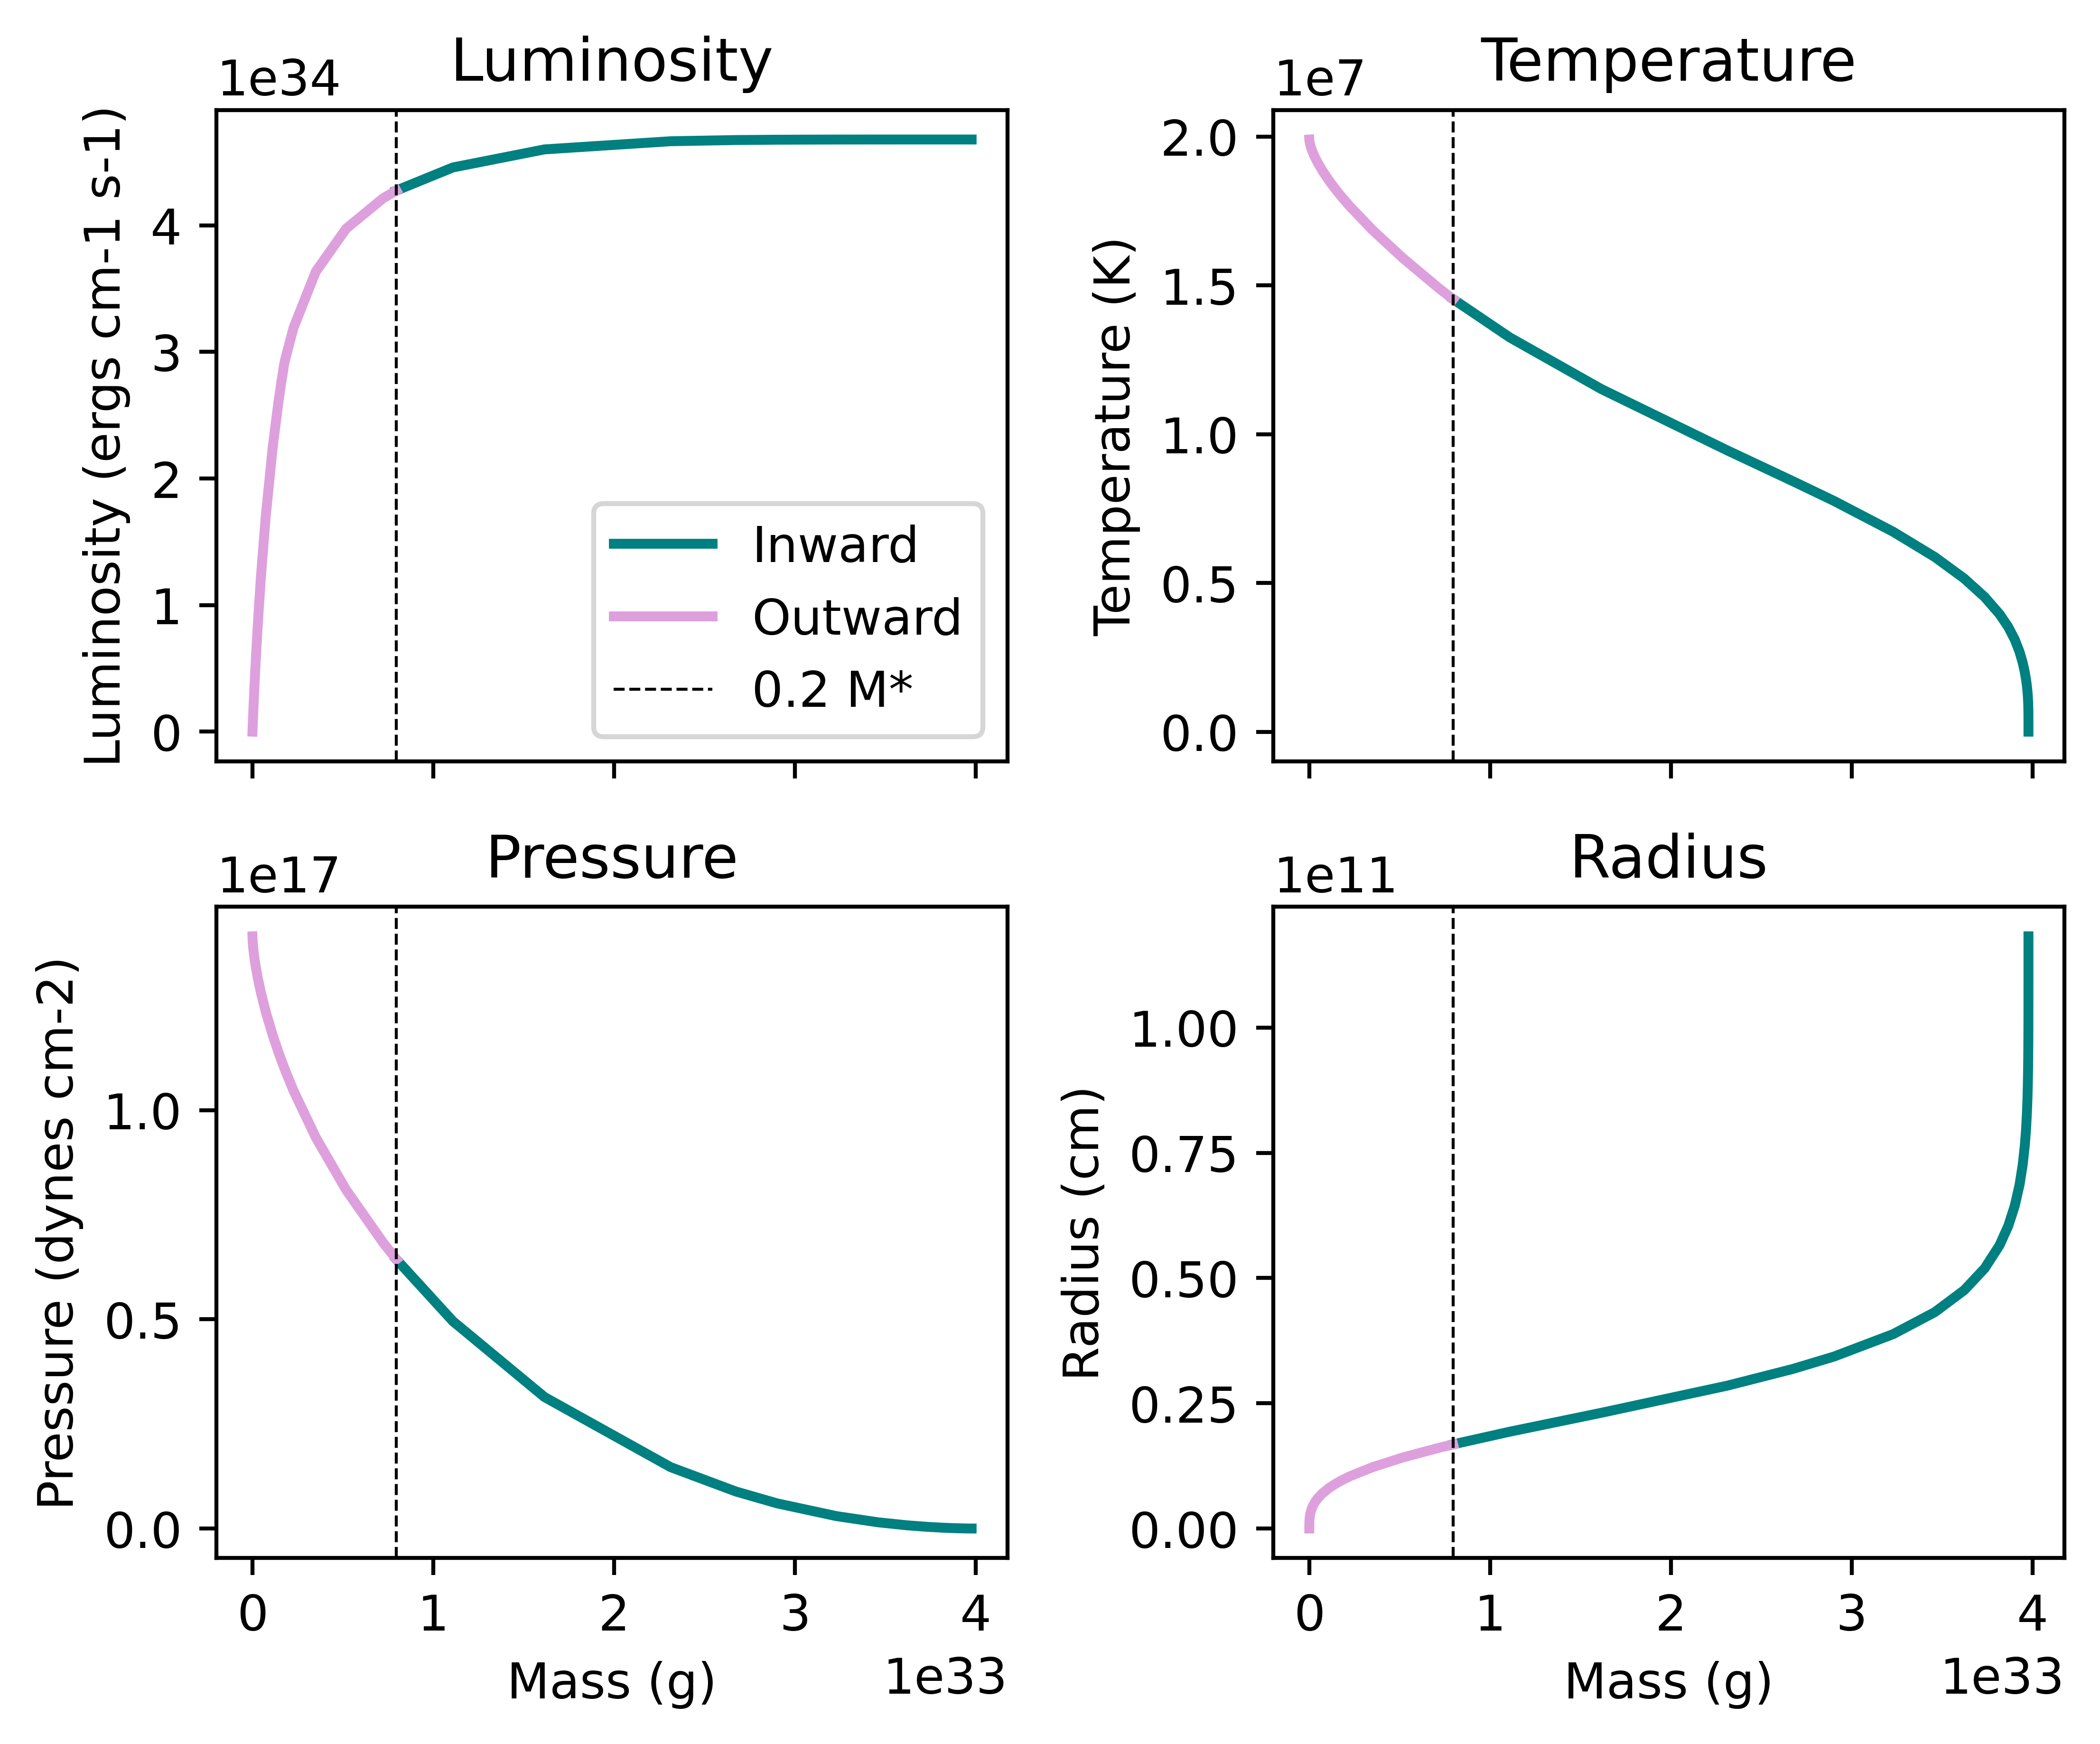

In [8]:
# central density value seems fine but seems like the opacity table can't read the R value -> R value ~ 10 right now but want it to be like <8.70 

fig, axes = plt.subplots(2, 2, sharex=True, dpi=750, figsize=(6,5))
axes = axes.flatten()

color_in = "teal"
color_out = "plum"

axes[0].set_title("Luminosity")
axes[0].plot(plot_dict["m_in"], plot_dict["params_in"]["lum"], color=color_in, linewidth=2, label="Inward")
axes[0].plot(plot_dict["m_out"], plot_dict["params_out"]["lum"], color=color_out, linewidth=2, label="Outward")
axes[0].set_ylabel("Luminosity (ergs cm-1 s-1)")
axes[0].axvline(0.2*Ms, color="k", linestyle='--', linewidth=0.6, label="0.2 M*")
#axes[0].semilogx()
#axes[0].semilogy()

axes[1].set_title("Temperature")
axes[1].plot(plot_dict["m_in"], plot_dict["params_in"]["temp"], color=color_in, linewidth=2)
axes[1].plot(plot_dict["m_out"], plot_dict["params_out"]["temp"], color=color_out, linewidth=2)
axes[1].set_ylabel("Temperature (K)")
axes[1].axvline(0.2*Ms, color="k", linestyle='--', linewidth=0.6)
#axes[1].semilogy()


axes[2].set_title("Pressure")
axes[2].plot(plot_dict["m_in"], plot_dict["params_in"]["pressure"], color=color_in, linewidth=2)
axes[2].plot(plot_dict["m_out"], plot_dict["params_out"]["pressure"], color=color_out, linewidth=2)
axes[2].set_xlabel("Mass (g)")
axes[2].set_ylabel("Pressure (dynes cm-2)")
axes[2].axvline(0.2*Ms, color="k", linestyle='--', linewidth=0.6)
#axes[2].semilogy()


axes[3].set_title("Radius")
axes[3].plot(plot_dict["m_in"], plot_dict["params_in"]["radius"], color=color_in, linewidth=2)
axes[3].plot(plot_dict["m_out"], plot_dict["params_out"]["radius"], color=color_out, linewidth=2)
axes[3].set_xlabel("Mass (g)")
axes[3].set_ylabel("Radius (cm)")
axes[3].axvline(0.2*Ms, color="k", linestyle='--', linewidth=0.6)

#axes[3].semilogy()

axes[0].legend(frameon=True)
fig.tight_layout()
plt.savefig("plots/mass_temp_press_lum_4panel.png")

# calculate everything 

In [25]:
mass_arr = np.concatenate((plot_dict["m_in"], plot_dict["m_out"][::-1]))
lum_arr =  np.concatenate((plot_dict["params_in"]["lum"], plot_dict["params_out"]["lum"][::-1]))
temp_arr = np.concatenate((plot_dict["params_in"]["temp"], plot_dict["params_out"]["temp"][::-1]))
pressure_arr = np.concatenate((plot_dict["params_in"]["pressure"], plot_dict["params_out"]["pressure"][::-1]))
radius_arr = np.concatenate((plot_dict["params_in"]["radius"], plot_dict["params_out"]["radius"][::-1]))

X, Y, Z = comp
# calc density 
rho_arr = rho_eq(pressure_arr, temp_arr, comp)

# calc energy gen rate
energy_gen_arr = e_CNO(X, Y, Z, rho_arr, temp_arr) + e_PP(X, Y, Z, rho_arr, temp_arr)

# calc radiative vs convective 
rad_conv_arr = []
for (m, T, P, L) in zip(mass_arr, temp_arr, pressure_arr, lum_arr):
    rad_conv_arr.append(check_nabla(comp, m, T, P, L, return_conv_rad = True))

# find turning points 
turning_masses = []
for i, (mass, state) in enumerate(zip(mass_arr[:-1], rad_conv_arr[:-1])):
    if rad_conv_arr[i+1] != state: 
        turning_masses.append(mass)
        

# calc opacity
opacity_arr = []
for T, rho in zip(temp_arr, rho_arr):
    logT = np.log10(T)
    logrho = np.log10(rho)
    opacity_arr.append(calc_k(logT, logrho))

# calc adiabatic temp gradient 


# calc stellar gradient dlnT/dlnP
#stellar_gradient_arr = 


In [31]:
turning_masses

[np.float64(3.9779999999881453e+33),
 np.float64(3.977999999687248e+33),
 np.float64(7.220153821457691e+32)]

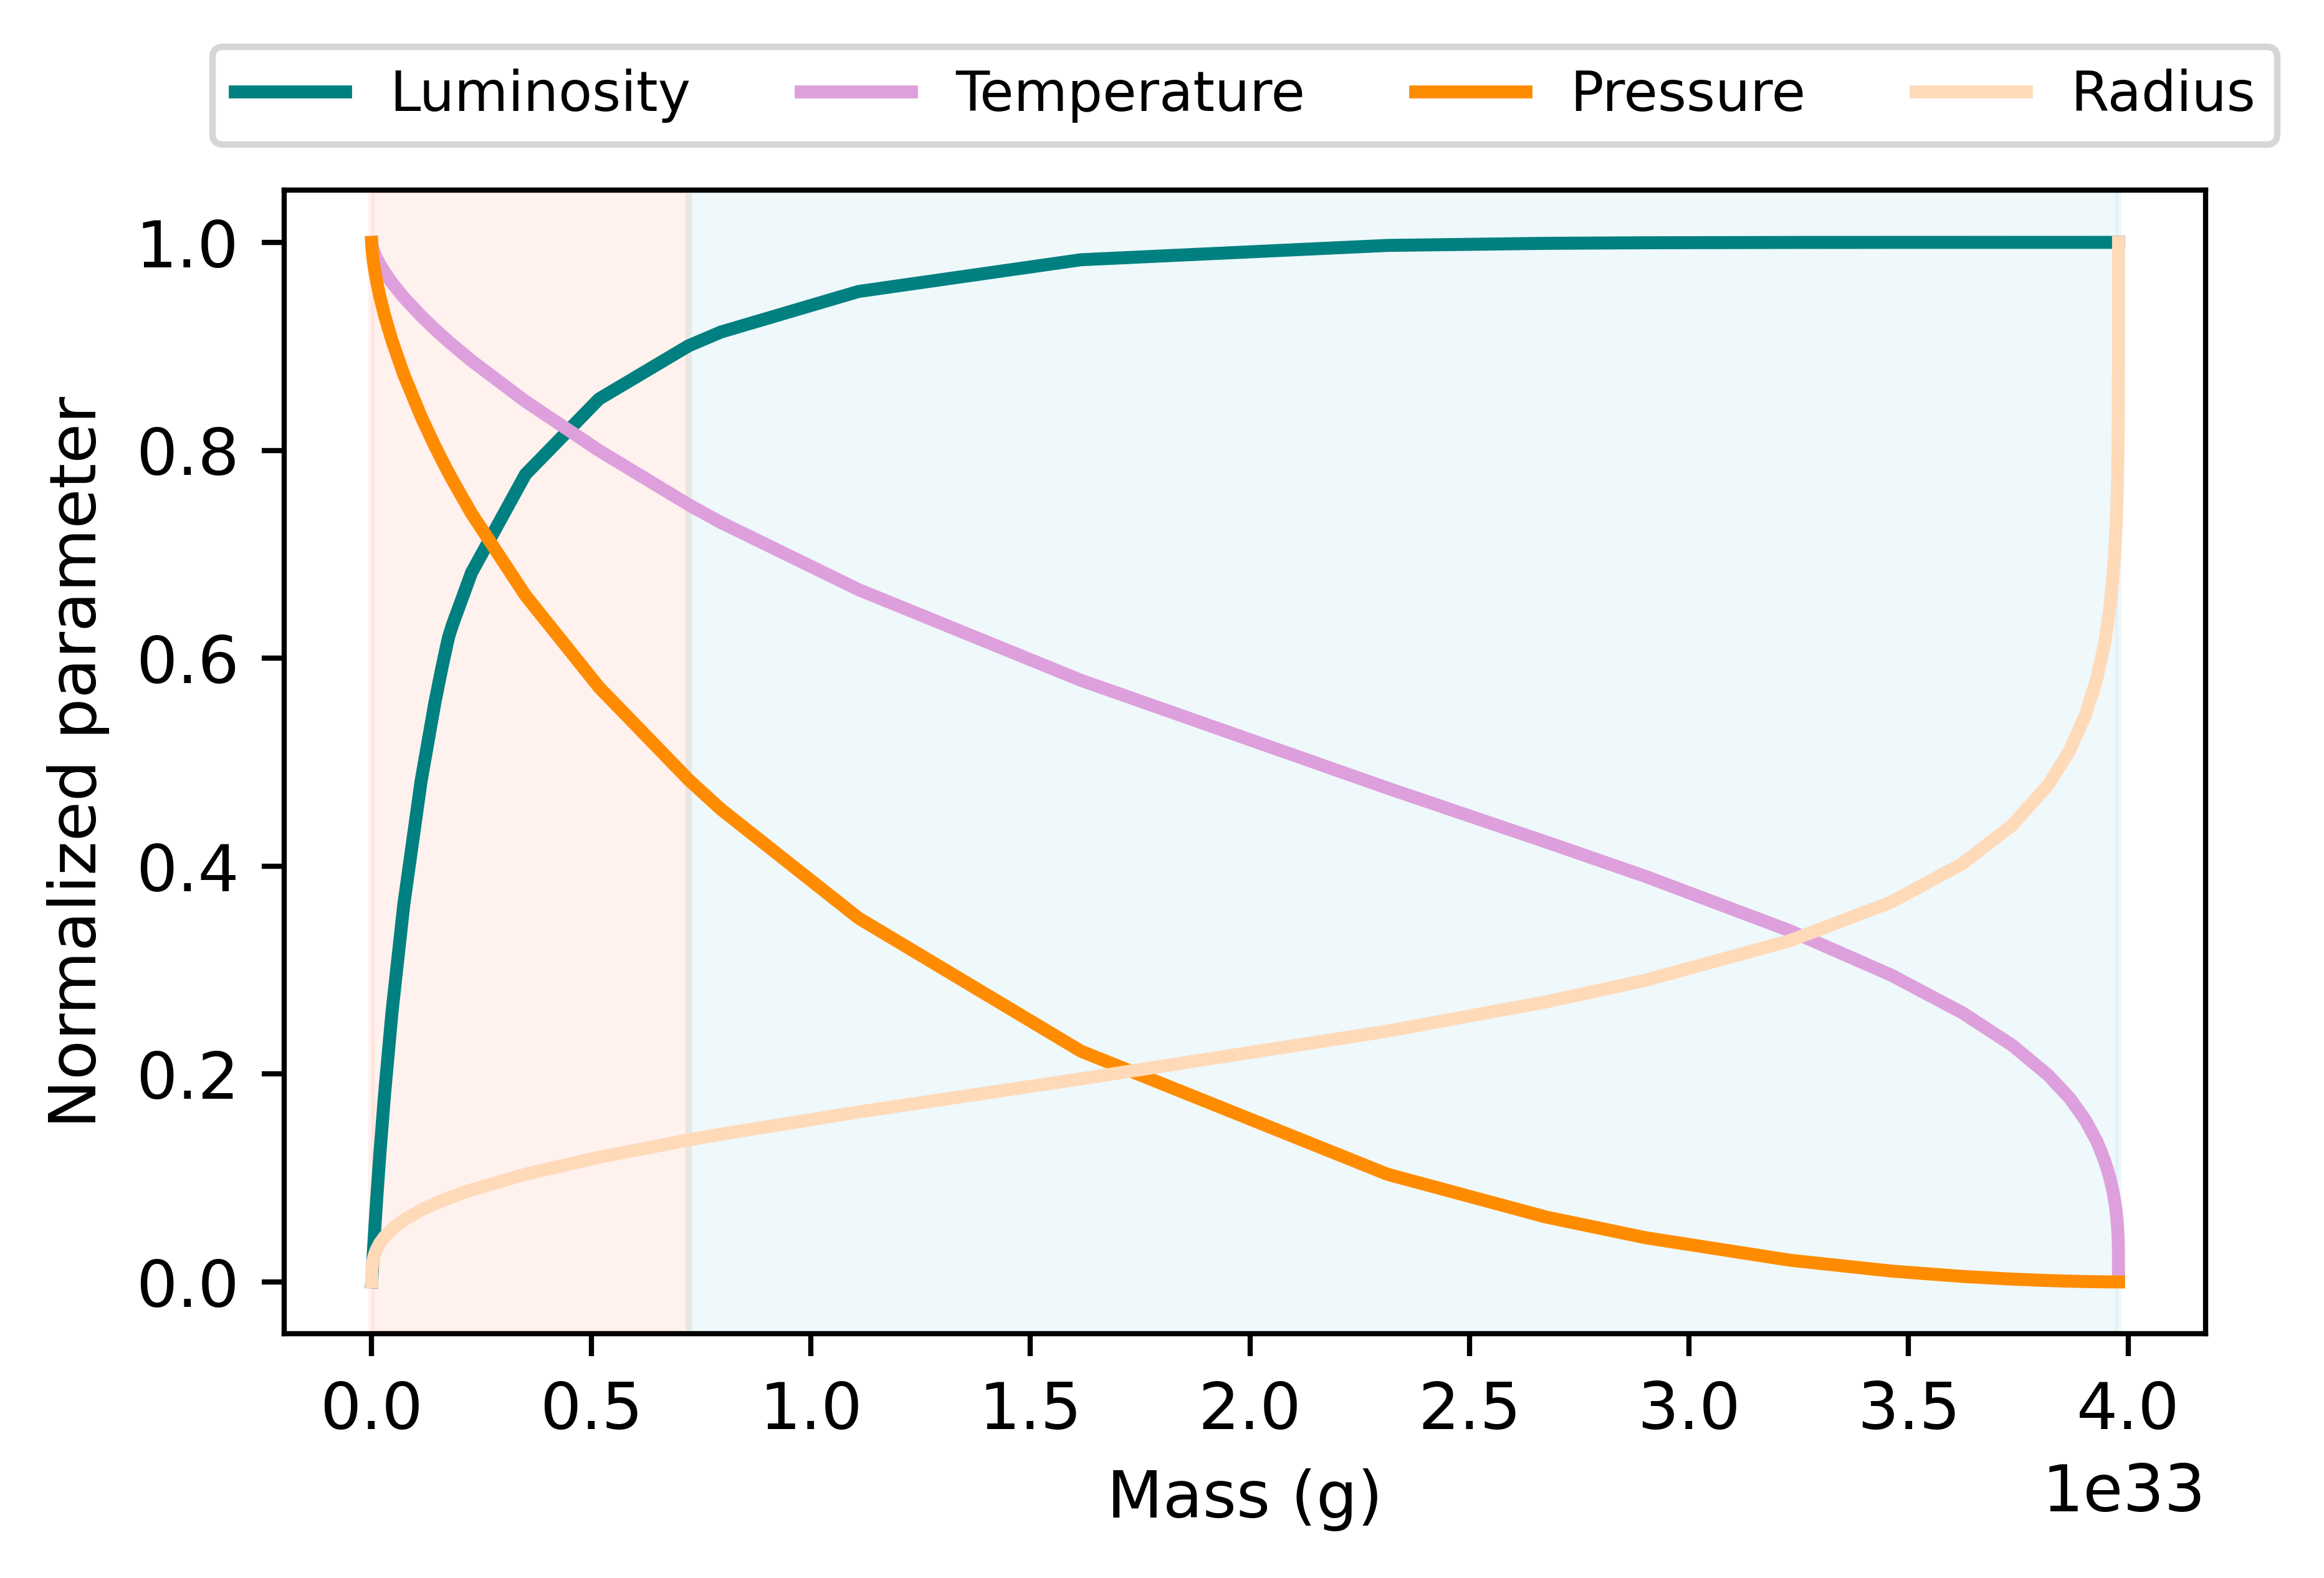

In [58]:
# normalized 

# central density value seems fine but seems like the opacity table can't read the R value -> R value ~ 10 right now but want it to be like <8.70 

fig, axes = plt.subplots(1, sharex=True, dpi=750, figsize=(5,3.5))

color_lum = "teal"
color_temp = "plum"
color_press = "darkorange"
color_rad = "peachpuff"

axes.plot(mass_arr, lum_arr/np.max(lum_arr), color=color_lum, linewidth=2, label="Luminosity")

axes.plot(mass_arr, temp_arr/np.max(temp_arr), color=color_temp, linewidth=2, label="Temperature")

axes.plot(mass_arr, pressure_arr/np.max(pressure_arr), color=color_press, linewidth=2, label="Pressure")

axes.plot(mass_arr, radius_arr/np.max(radius_arr), color=color_rad, linewidth=2, label="Radius")

# plot rad vs convective 
axes.axvspan(0, turning_masses[2], color="coral", alpha=0.1)
axes.axvspan(turning_masses[1], turning_masses[2], color="powderblue", alpha=0.2)

#axes.semilogy()
plt.legend(loc='upper center', 
           bbox_to_anchor=(0.5, 1.15), 
           ncol=4, fontsize=8.5)
fig.tight_layout()
axes.set_xlabel("Mass (g)")
axes.set_ylabel("Normalized parameter")
#plt.ylim(1e-3, 1e2)
plt.savefig("plots/mass_temp_press_lum_one.png")

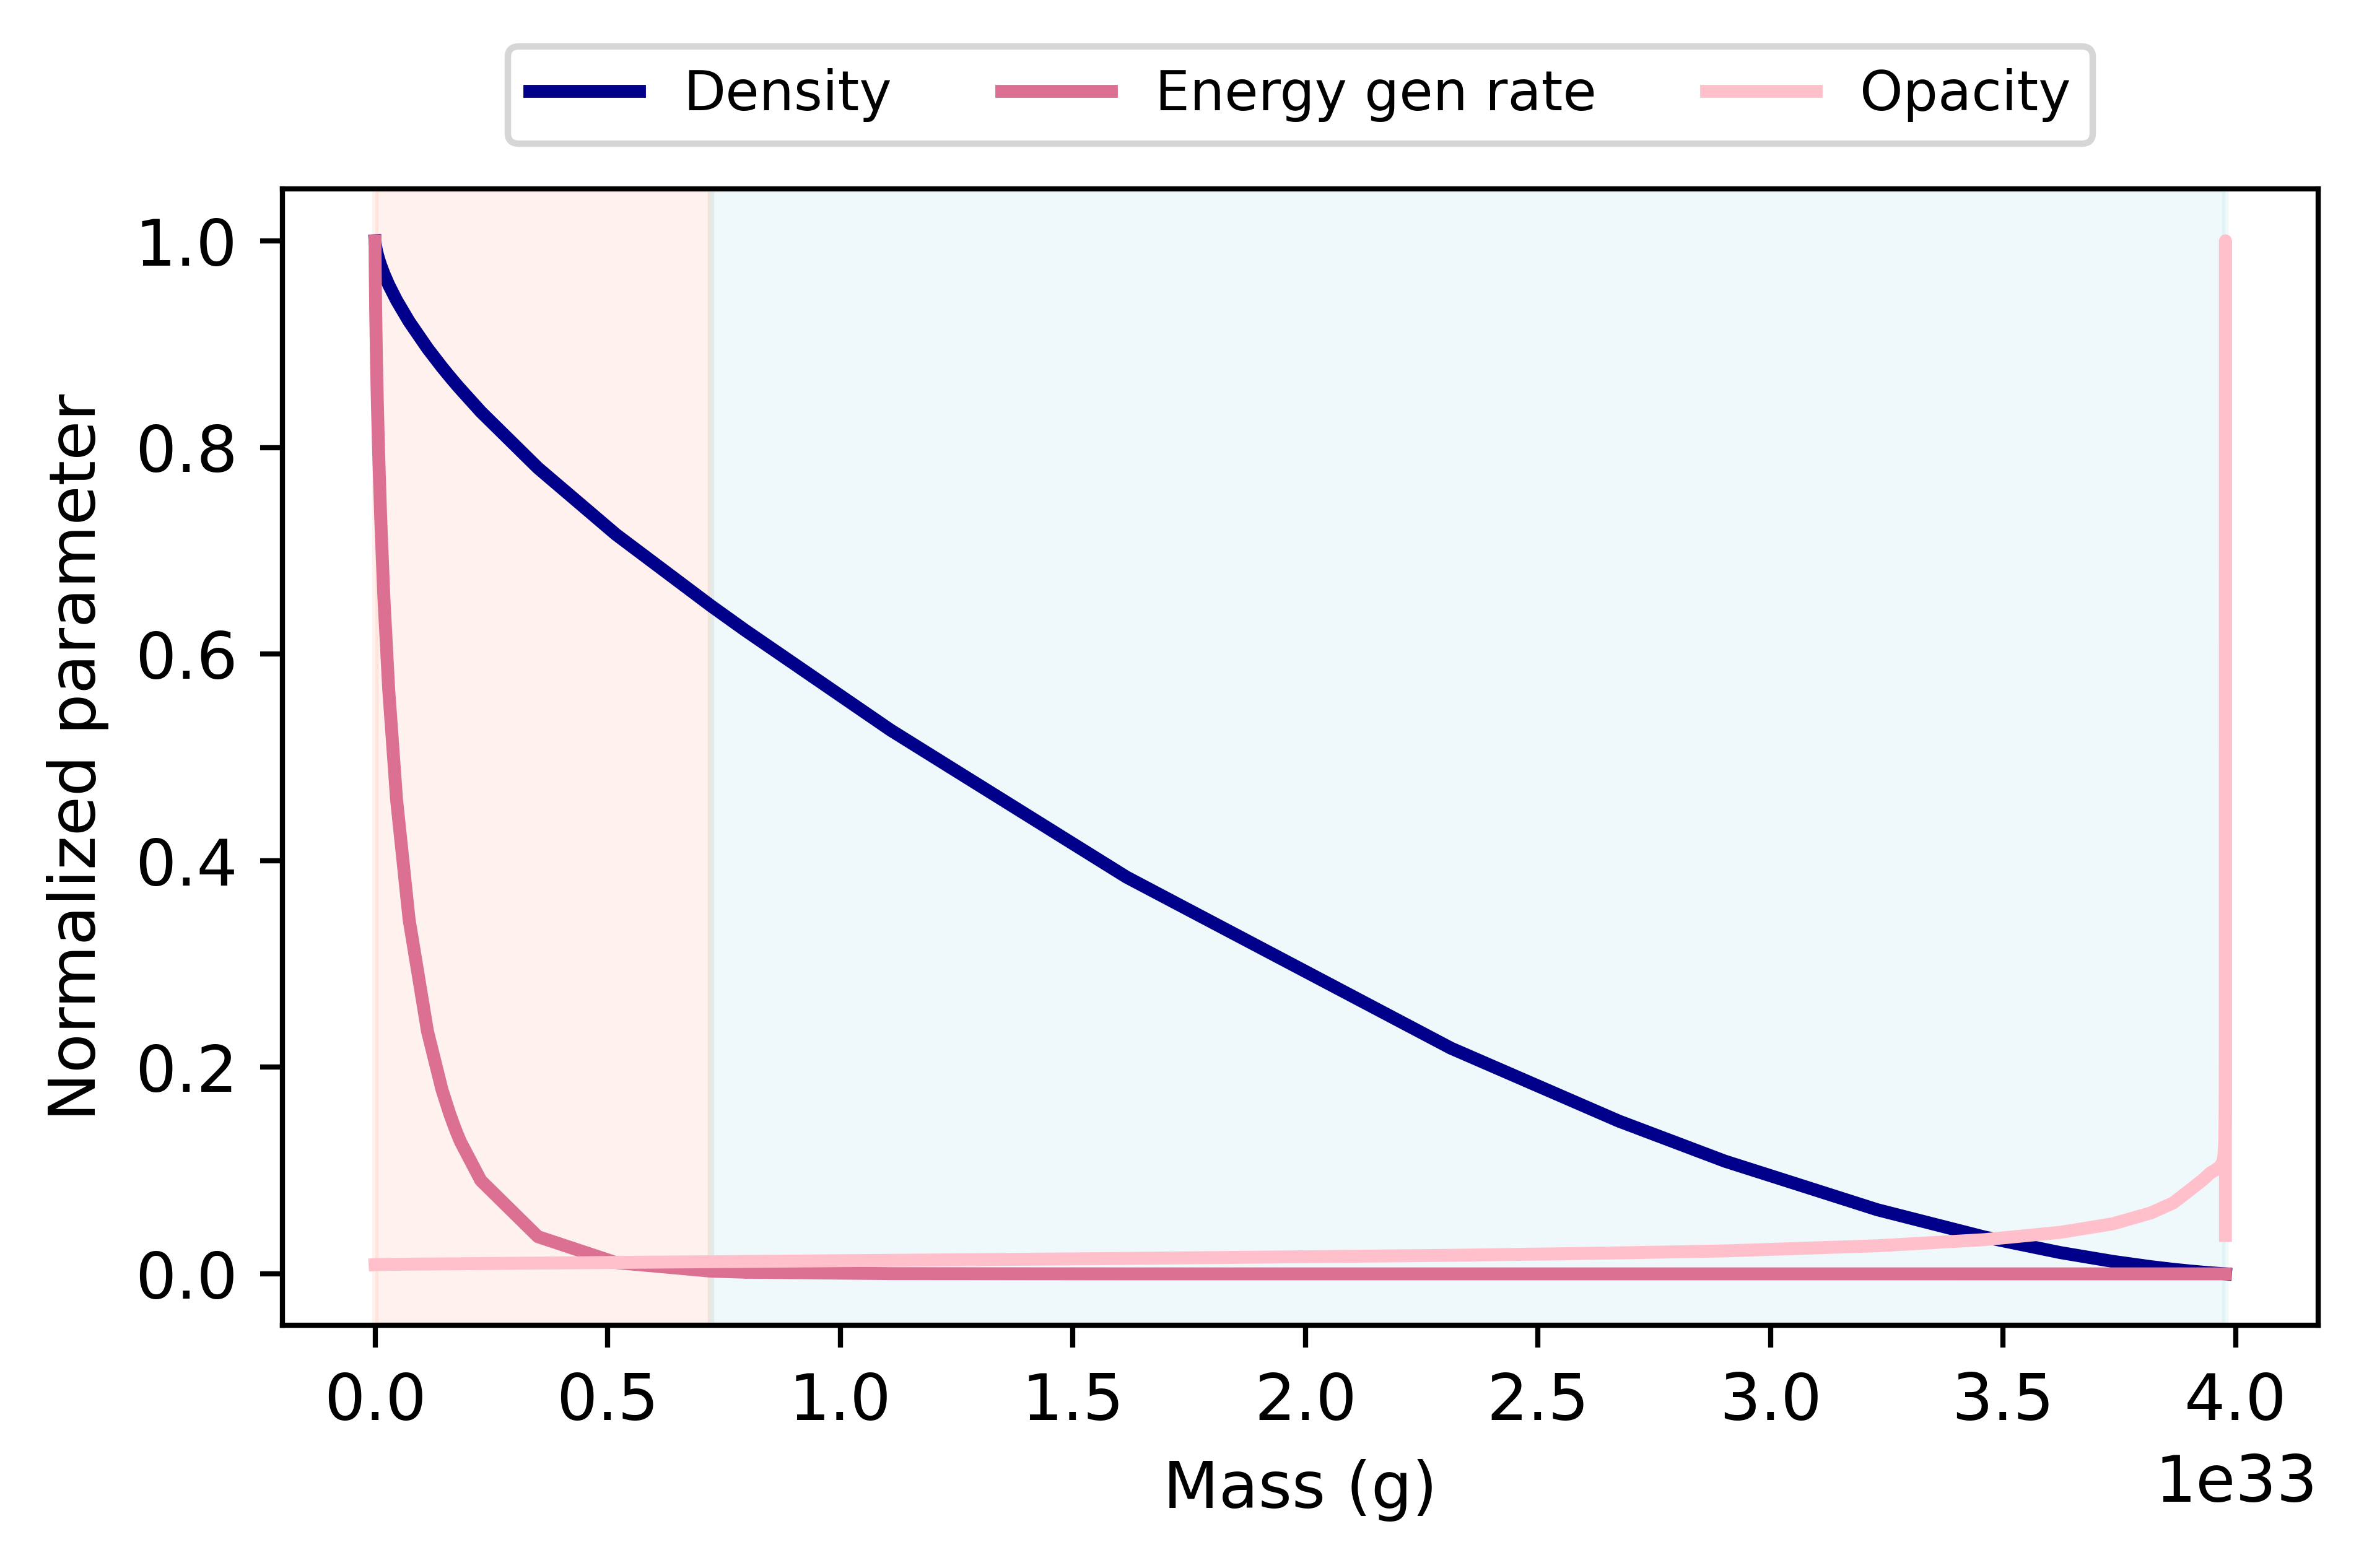

In [59]:
# normalized 

# central density value seems fine but seems like the opacity table can't read the R value -> R value ~ 10 right now but want it to be like <8.70 

fig, axes = plt.subplots(1, sharex=True, dpi=750, figsize=(5,3.5))

color_rho = "darkblue"
color_e = "palevioletred"
color_opacity = "pink"
#color_rad = "peachpuff"

axes.plot(mass_arr, rho_arr/np.max(rho_arr), color=color_rho, linewidth=2, label="Density")

axes.plot(mass_arr, energy_gen_arr/np.max(energy_gen_arr), color=color_e, linewidth=2, label="Energy gen rate")

axes.plot(mass_arr, opacity_arr/np.max(opacity_arr), color=color_opacity, linewidth=2, label="Opacity")

# plot rad convective zones
axes.axvspan(0, turning_masses[2], color="coral", alpha=0.1)
axes.axvspan(turning_masses[1], turning_masses[2], color="powderblue", alpha=0.2)

#axes.semilogy()
plt.legend(loc='upper center', 
           bbox_to_anchor=(0.5, 1.15), 
           ncol=4, fontsize=8.5)
fig.tight_layout()
axes.set_xlabel("Mass (g)")
axes.set_ylabel("Normalized parameter")
#plt.ylim(1e-3, 1e2)
plt.savefig("plots/rho_e_k_nablas_one.png")

Text(0, 0.5, 'pressure')

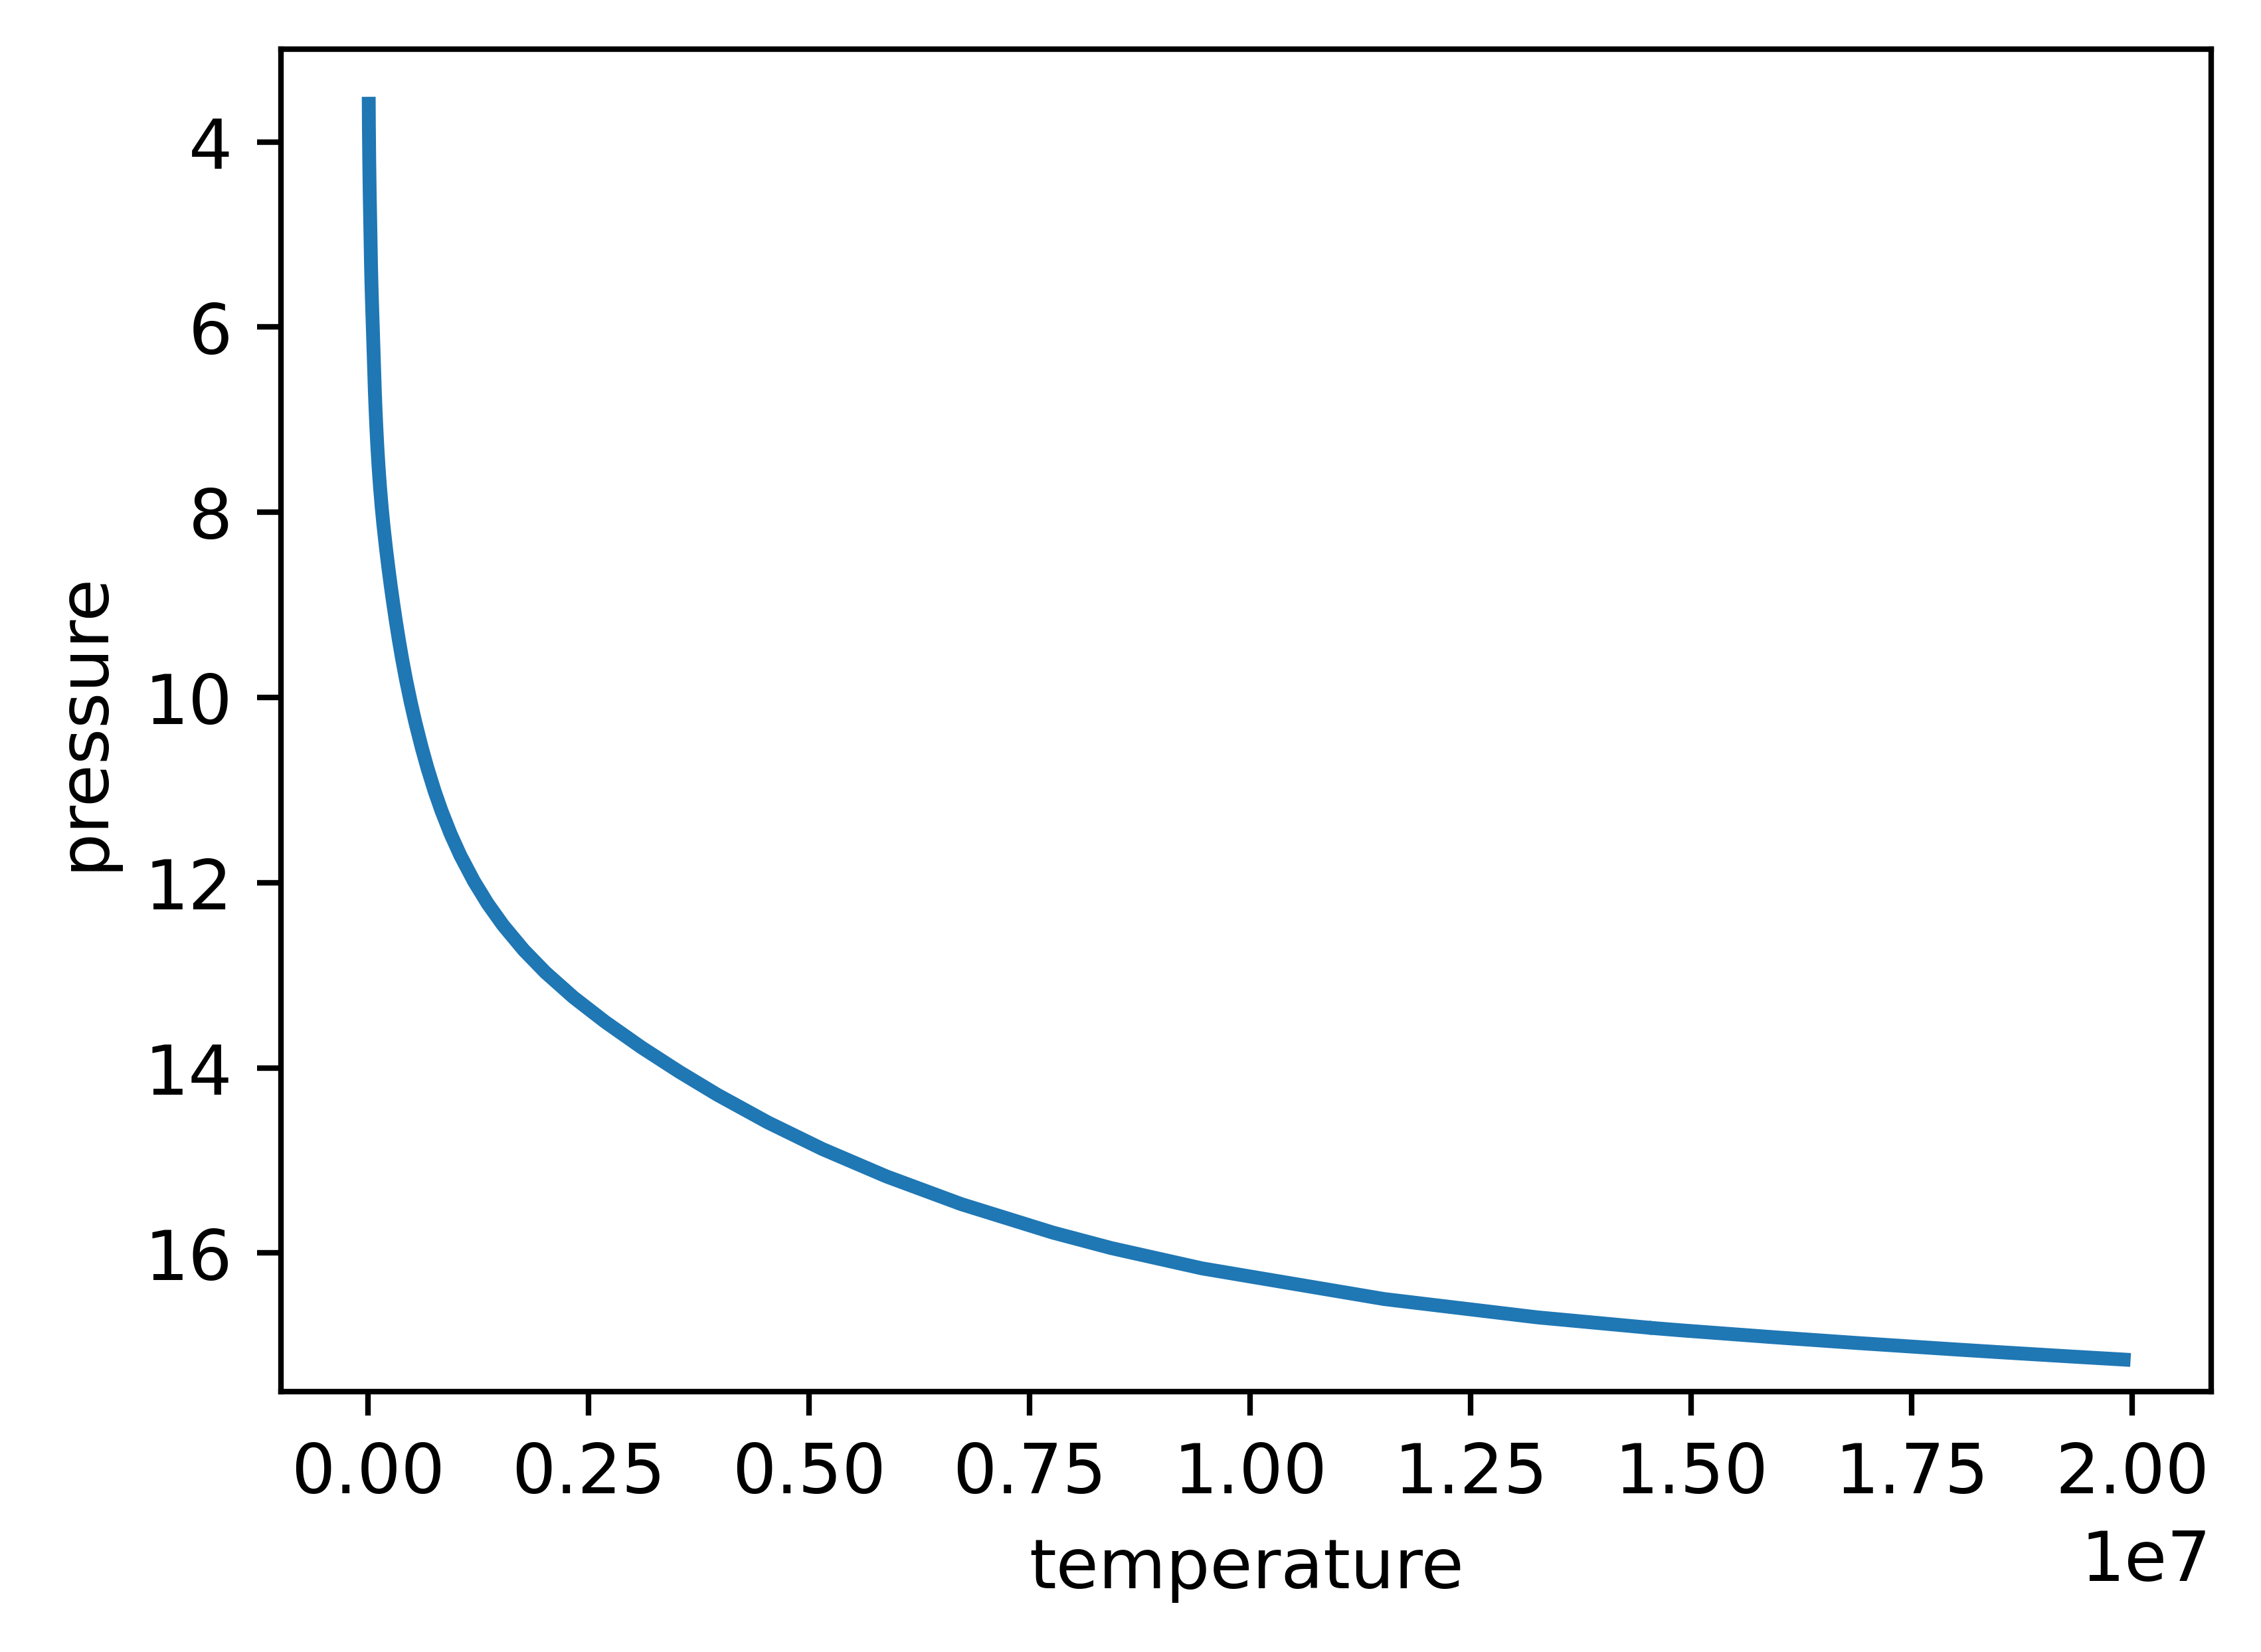

In [76]:
# normalized 

# central density value seems fine but seems like the opacity table can't read the R value -> R value ~ 10 right now but want it to be like <8.70 

fig, axes = plt.subplots(1, sharex=True, dpi=750, figsize=(5,3.5))

color_lum = "teal"
color_temp = "plum"
color_press = "darkorange"
color_rad = "peachpuff"


axes.plot(temp_arr, np.log10(pressure_arr), linewidth=2, label="Temperature")
axes.set_ylim(17.5,3)

#plt.semilogy()

plt.xlabel("temperature")
plt.ylabel("pressure")
